In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("C:/Users/keerthana/Downloads/Social_Media.csv")

df.head()

,Account ID,Username,Platform,Follower Count,Posts Per Week,Engagement Rate,Ad Spend (USD),Conversion Rate,Campaign Reach
0,1,harrislisa,TikTok,54217,3,0.0986,538.10,0.0490,1308
1,2,rhicks,LinkedIn,987518,5,0.0834,479.24,0.0174,13302
2,3,qthomas,Facebook,218870,3,0.1020,150.36,0.0318,11043
3,4,carlosholt,Instagram,207432,6,0.0834,932.62,0.0400,12074
4,5,parsonsashley,Facebook,350204,2,0.0642,504.44,0.0463,14083


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns in Dataset:")
print(df.columns)

print("\nDataset Info:")
df.info()

Dataset Shape: (10016, 9)

Columns in Dataset:
Index(['Account ID', 'Username', 'Platform', 'Follower Count',
       'Posts Per Week', 'Engagement Rate', 'Ad Spend (USD)',
       'Conversion Rate', 'Campaign Reach'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10016 entries, 0 to 10015
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Account ID       10016 non-null  int64  
 1   Username         10016 non-null  object 
 2   Platform         10016 non-null  object 
 3   Follower Count   10016 non-null  int64  
 4   Posts Per Week   10016 non-null  int64  
 5   Engagement Rate  10016 non-null  float64
 6   Ad Spend (USD)   10016 non-null  float64
 7   Conversion Rate  10016 non-null  float64
 8   Campaign Reach   10016 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 704.4+ KB


In [7]:
df.isnull().sum()

Account ID         0
Username           0
Platform           0
Follower Count     0
Posts Per Week     0
Engagement Rate    0
Ad Spend (USD)     0
Conversion Rate    0
Campaign Reach     0
dtype: int64

In [9]:
# remove duplicates
df = df.drop_duplicates()

# numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# fill missing numeric values
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# fill missing categorical values
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()

C:\Users\keerthana\AppData\Local\Temp\ipykernel_29860\4203121132.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Account ID         0
Username           0
Platform           0
Follower Count     0
Posts Per Week     0
Engagement Rate    0
Ad Spend (USD)     0
Conversion Rate    0
Campaign Reach     0
dtype: int64

In [11]:
print("Basic Statistics")
df.describe()

df.mean(numeric_only=True)

df.median(numeric_only=True)

Basic Statistics


Account ID           5000.5000
Follower Count     506529.0000
Posts Per Week          4.0000
Engagement Rate         0.0856
Ad Spend (USD)        517.5600
Conversion Rate         0.0284
Campaign Reach      25260.0000
dtype: float64

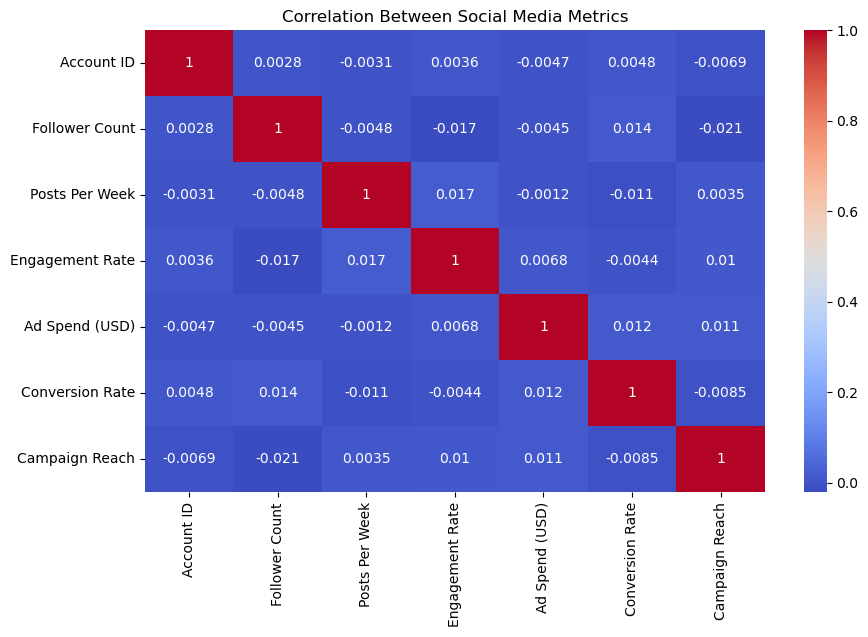

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Social Media Metrics")

plt.show()

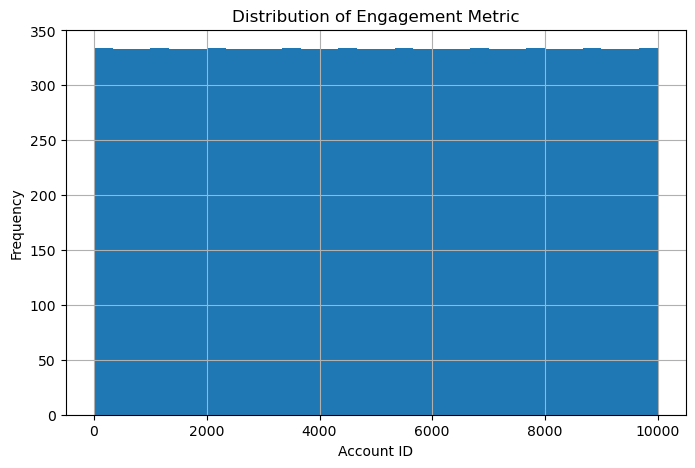

In [15]:
plt.figure(figsize=(8,5))

df[numeric_cols[0]].hist(bins=30)

plt.title("Distribution of Engagement Metric")

plt.xlabel(numeric_cols[0])
plt.ylabel("Frequency")

plt.show()

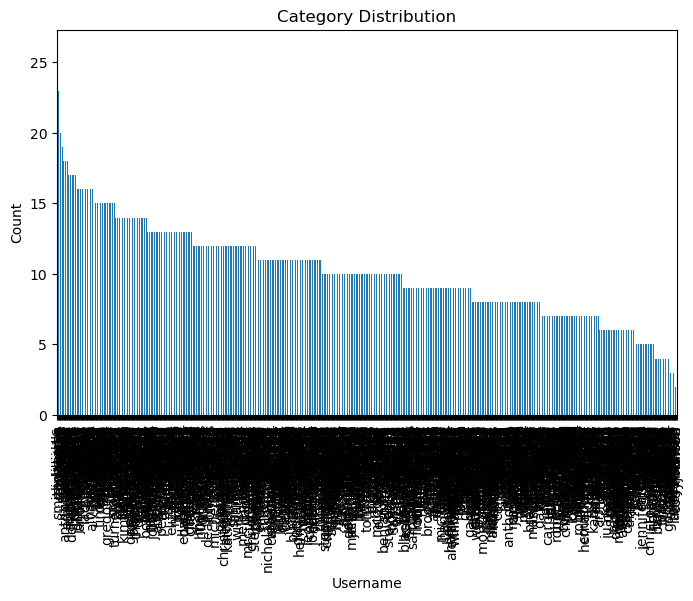

In [17]:
if len(categorical_cols) > 0:

    plt.figure(figsize=(8,5))

    df[categorical_cols[0]].value_counts().plot(kind="bar")

    plt.title("Category Distribution")

    plt.xlabel(categorical_cols[0])
    plt.ylabel("Count")

    plt.show()

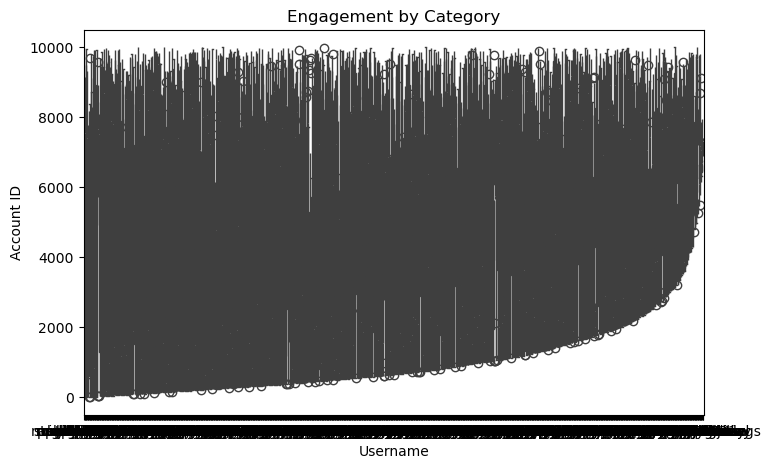

In [18]:
if len(categorical_cols) > 0 and len(numeric_cols) > 0:

    plt.figure(figsize=(8,5))

    sns.boxplot(x=df[categorical_cols[0]], y=df[numeric_cols[0]])

    plt.title("Engagement by Category")

    plt.show()

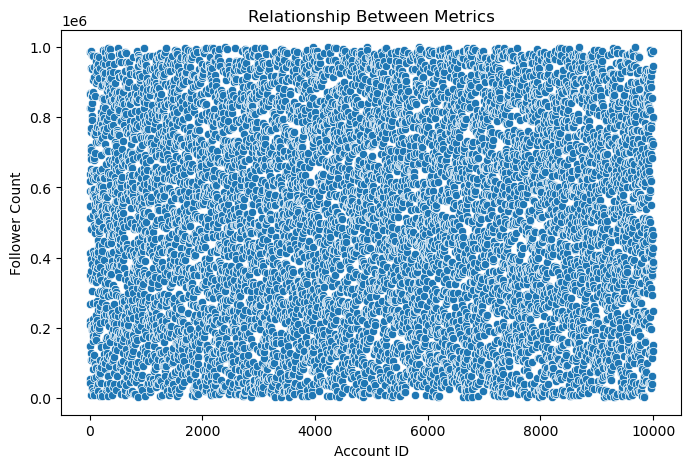

In [20]:
if len(numeric_cols) >= 2:

    plt.figure(figsize=(8,5))

    sns.scatterplot(x=df[numeric_cols[0]], y=df[numeric_cols[1]])

    plt.title("Relationship Between Metrics")

    plt.xlabel(numeric_cols[0])
    plt.ylabel(numeric_cols[1])

    plt.show()

In [23]:
print("===== SOCIAL MEDIA INSIGHTS =====")

print("Average value:", df[numeric_cols[0]].mean())

print("Median value:", df[numeric_cols[0]].median())

print("\nTop correlations:")

print(corr.unstack().sort_values(ascending=False)[1:6])

if len(categorical_cols) > 0:
    print("\nMost frequent category:", df[categorical_cols[0]].value_counts().idxmax())

===== SOCIAL MEDIA INSIGHTS =====
Average value: 5000.5
Median value: 5000.5

Top correlations:
Follower Count   Follower Count     1.0
Conversion Rate  Conversion Rate    1.0
Ad Spend (USD)   Ad Spend (USD)     1.0
Posts Per Week   Posts Per Week     1.0
Engagement Rate  Engagement Rate    1.0
dtype: float64

Most frequent category: michael16


In [25]:
df.to_csv("cleaned_social_media_data.csv", index=False)

print("Cleaned dataset saved.")

Cleaned dataset saved.
